# Bagging Classifier Naive Bayes (Ecoli)

Ini adalah tahap modeling klasifikasi data Ecoli menggunakan metode Bagging Classifier dengan **Naive Bayes**, pada kondisi:

Data Ecoli yang belum dilakukan oversampling.

Data Ecoli yang sudah dilakukan oversampling menggunakan SMOTE.

Data Ecoli yang sudah dilakukan oversampling menggunakan ADASYN.

Metode Bagging Classifier dipilih karena mampu meningkatkan stabilitas dan akurasi model dengan cara menggabungkan beberapa model dasar melalui teknik bootstrap aggregating. Pada penelitian ini, digunakan dua model dasar yang berbeda. Naive Bayes dipilih karena kesederhanaannya dan kecepatannya dalam memproses data, sedangkan Decision Tree dipilih karena kemampuannya membentuk aturan yang lebih kompleks.

Kedua algoritma tersebut kemudian dibungkus (wrapped) ke dalam Bagging Classifier dan dievaluasi pada tiga kondisi data (asli, SMOTE, dan ADASYN). Tujuannya adalah untuk mengetahui apakah terjadi peningkatan akurasi setelah dilakukan oversampling, sekaligus membandingkan kinerja Bagging Classifier dengan dua model dasar yang berbeda.

# Library yang diperlukan 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sqlalchemy import create_engine
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\__init__.py:159: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.0.2)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\runpy.py", lin

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

# BaggingClassifier Menggunakan Metode Naive Bayes

Ini adalah tahap modeling klasifikasi data Ecoli menggunakan metode Bagging Classifier dengan model dasar Naive Bayes. Data diuji pada tiga kondisi, yaitu data asli (belum dilakukan oversampling), data hasil oversampling dengan SMOTE, dan data hasil oversampling dengan ADASYN.

## Bagging Classifier pada data yang belum di lakukan oversampling


c:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
c:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
c:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
c:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
c:\Users\USERB-PC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
c:\Users\USERB-PC\AppData\Local\Pro

Akurasi: 0.75
Classification Report:
               precision    recall  f1-score   support

          cp       0.91      0.94      0.92        32
          im       0.59      0.77      0.67        13
         imS       0.00      0.00      0.00         1
         imU       0.00      0.00      0.00         4
          om       1.00      0.33      0.50         6
         omL       1.00      1.00      1.00         1
          pp       0.57      0.73      0.64        11

    accuracy                           0.75        68
   macro avg       0.58      0.54      0.53        68
weighted avg       0.74      0.75      0.72        68



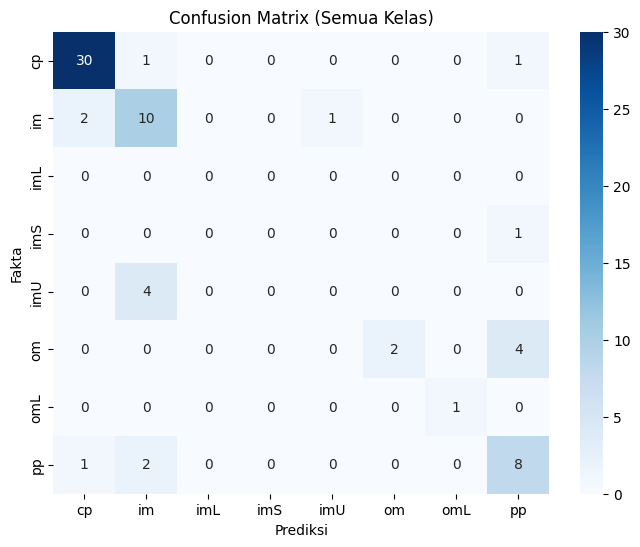

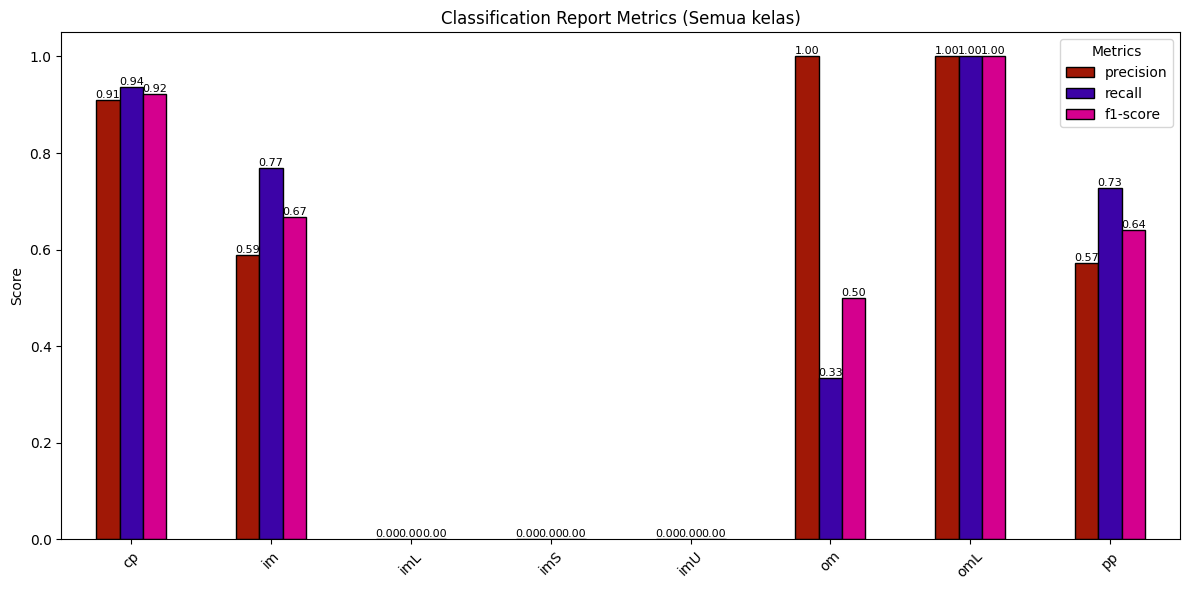

In [19]:
engine = create_engine("mysql+pymysql://root:@localhost/psd")
query = "SELECT mcg, gvh, lip, chg, aac, alm1, alm2, localization_class FROM ecoli"
df = pd.read_sql(query, engine)

X = df.drop(columns=["localization_class"])
y = df["localization_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()

bagging = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)

prediksi = bagging.predict(X_test)
akurasi = accuracy_score(y_test, prediksi)
print("Akurasi:", akurasi)
print("Classification Report:\n", classification_report(y_test, prediksi, zero_division=0))

# confuison matrix

labels = np.unique(np.concatenate([y_train, y_test]))

cm = confusion_matrix(y_test, prediksi, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train, y_test]))

report = classification_report(
    y_test, prediksi, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], 
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## BaggingClassifier pada data yang sudah di lakukan oversampling dengan SMOTE


class
cp     143
im     143
imS    143
imL    143
imU    143
om     143
omL    143
pp     143
Name: count, dtype: int64
Akurasi :  0.8296943231441049
Classification Report:
               precision    recall  f1-score   support

          cp       1.00      0.97      0.98        32
          im       0.69      0.79      0.73        28
         imL       1.00      1.00      1.00        29
         imS       1.00      1.00      1.00        31
         imU       0.70      0.59      0.64        27
          om       1.00      0.28      0.43        29
         omL       0.95      1.00      0.97        19
          pp       0.62      1.00      0.76        34

    accuracy                           0.83       229
   macro avg       0.87      0.83      0.82       229
weighted avg       0.87      0.83      0.81       229



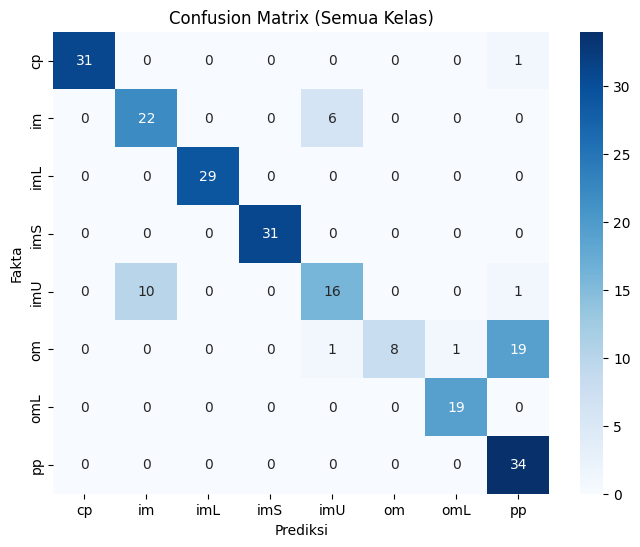

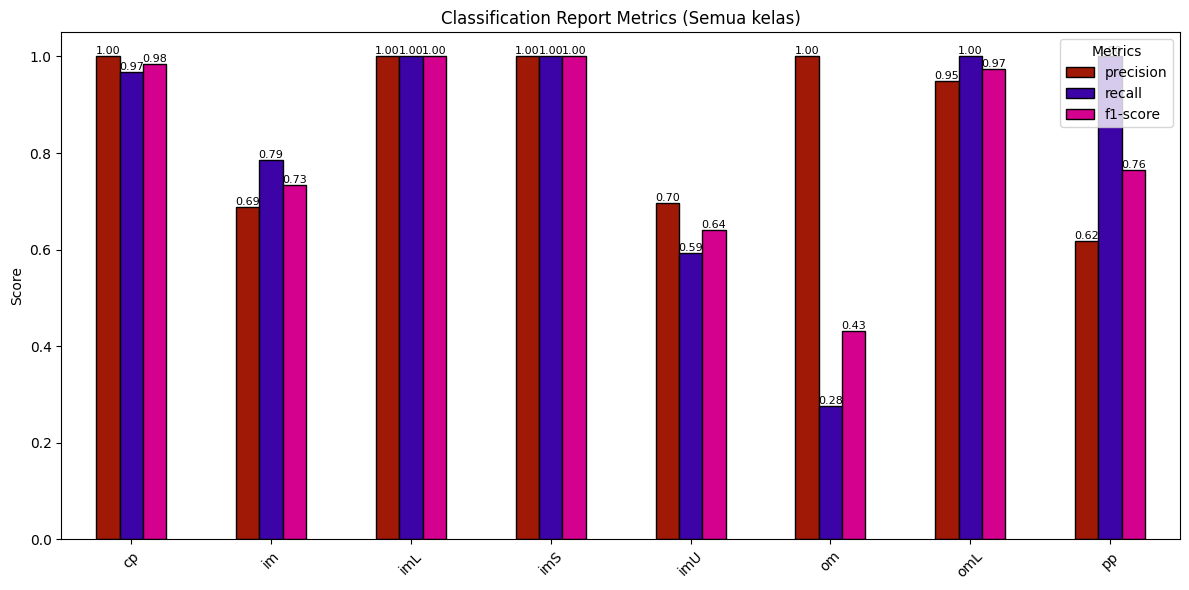

In [20]:

data_smote = pd.read_csv("../oversampling/hasil_oversampling_SMOTE.csv")
print(data_smote["class"].value_counts())
x_smote = data_smote.drop(columns=["class"])
y_smote = data_smote["class"]
data_smote


X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42
)

model = GaussianNB()
bagging_smote = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)

bagging_smote.fit(X_train_smote, y_train_smote)

prediksi_smote = bagging_smote.predict(X_test_smote)

akurasi_smote = accuracy_score(y_test_smote, prediksi_smote)
print("Akurasi : ", akurasi_smote)
print("Classification Report:\n", classification_report(y_test_smote, prediksi_smote, zero_division=0))


# confuison matrix
labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))

report = classification_report(
    y_test_smote, prediksi_smote, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], 
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## BaggingClassifier pada data yang sudah di lakukan oversampling dengan ADASYN


class
im     153
pp     145
imU    144
cp     143
om     143
omL    143
imS    142
imL    142
Name: count, dtype: int64
accuracy_score : 0.8571428571428571
Classification Report:
               precision    recall  f1-score   support

          cp       0.94      0.97      0.95        30
          im       0.93      0.48      0.63        27
         imL       1.00      1.00      1.00        31
         imS       0.92      1.00      0.96        33
         imU       0.79      0.91      0.85        33
          om       1.00      0.46      0.63        28
         omL       1.00      1.00      1.00        23
          pp       0.58      1.00      0.73        26

    accuracy                           0.86       231
   macro avg       0.89      0.85      0.84       231
weighted avg       0.89      0.86      0.85       231



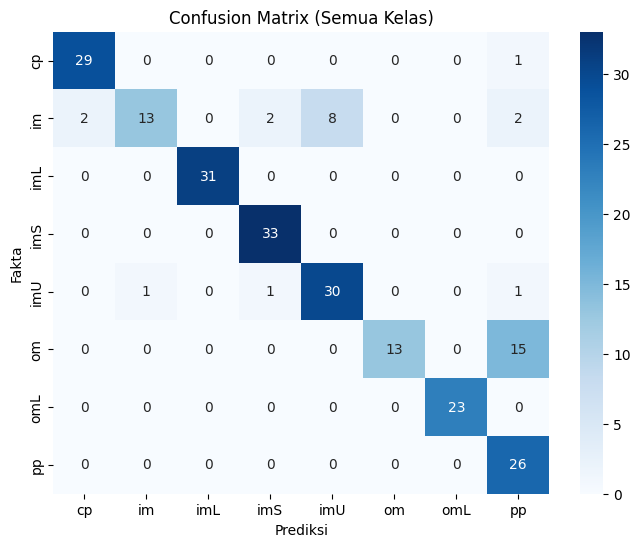

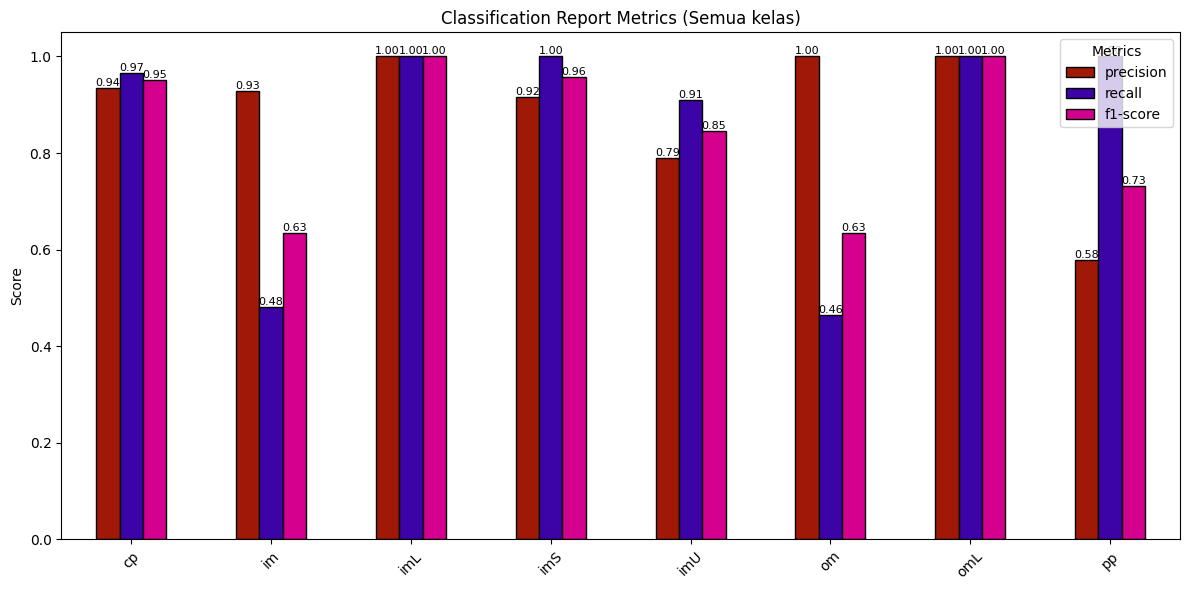

In [21]:

data_adasyn = pd.read_csv("../oversampling/hasil_oversampling_ADASYN.csv")
print(data_adasyn["class"].value_counts())
x_adasyn = data_adasyn.drop(columns=["class"])
y_adasyn = data_adasyn["class"]

X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    x_adasyn, y_adasyn, test_size=0.2, random_state=42
)

model = GaussianNB()

bagging_adasyn = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)

bagging_adasyn.fit(X_train_adasyn, y_train_adasyn)

prediksi_adasyn = bagging_adasyn.predict(X_test_adasyn)

akurasi_adasyn = accuracy_score(y_test_adasyn, prediksi_adasyn)
print(f"accuracy_score : {akurasi_adasyn}")
print("Classification Report:\n", classification_report(y_test_adasyn, prediksi_adasyn))

# confuison matrix

labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

report = classification_report(
    y_test_adasyn, prediksi_adasyn, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


# Perbandingan Akurasi Bagging Classifire dengan model Naive Bayes

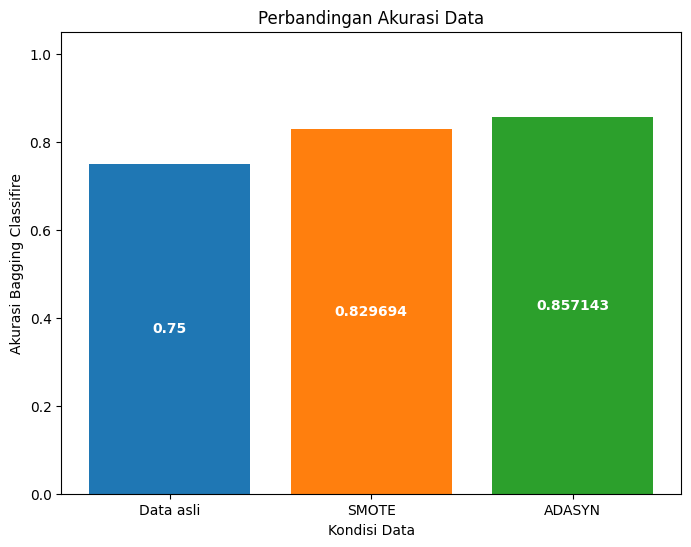

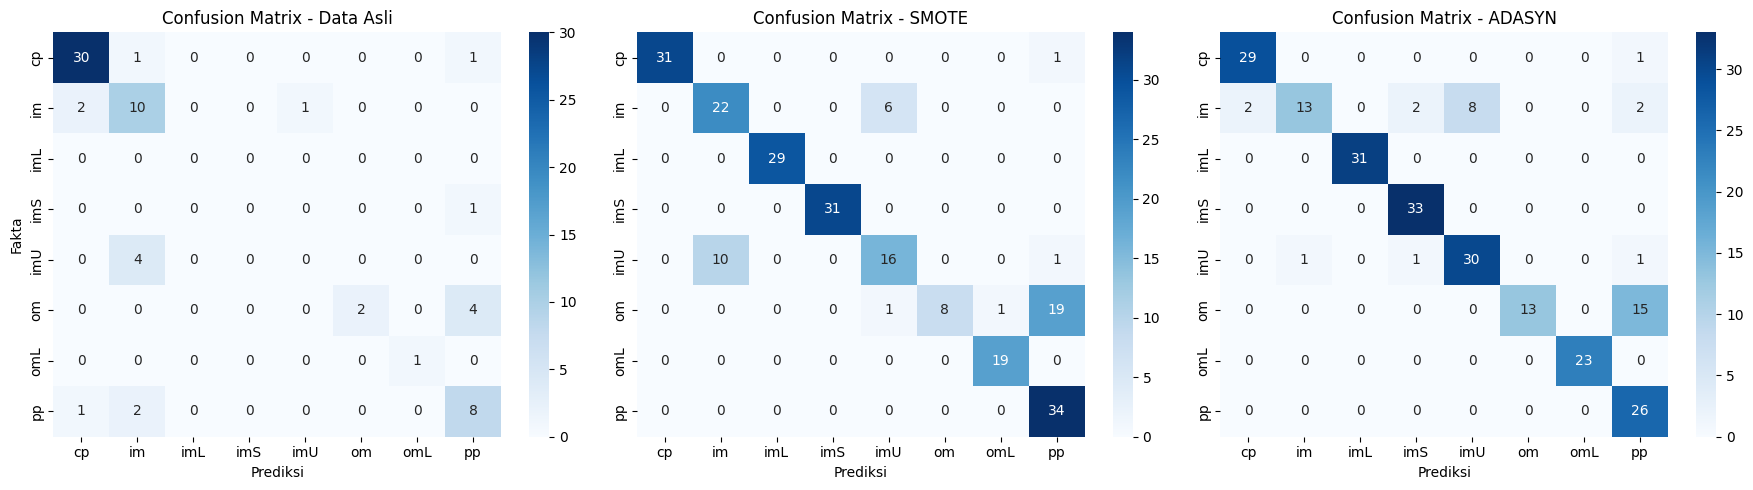

In [22]:

label = ['Data asli', 'SMOTE', 'ADASYN']
temp = [akurasi, akurasi_smote, akurasi_adasyn]

fig, ax = plt.subplots(figsize=(8,6))

bc = ax.bar(label, temp, color=['#1f77b4','#ff7f0e','#2ca02c'])

ax.bar_label(bc, label_type='center', color='w', fontweight='bold')

ax.set(
    xlabel='Kondisi Data',
    ylabel='Akurasi Bagging Classifire',
    title='Perbandingan Akurasi Data'
)

ax.set_ylim(0, 1.05)

plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data asli
labels = np.unique(np.concatenate([y_train, y_test]))
cm = confusion_matrix(y_test, prediksi, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix - Data Asli")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Fakta")

# Data SMOTE
labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))
cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix - SMOTE")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("")

# Data ADASYN
labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))
cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title("Confusion Matrix - ADASYN")
axes[2].set_xlabel("Prediksi")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

Berdasarkan grafik perbandingan akurasi Bagging Classifier dengan model Naive Bayes, dapat disimpulkan bahwa akurasi data asli masih lebih rendah yaitu sekitar 75%, sedangkan setelah dilakukan oversampling dengan SMOTE akurasi meningkat hingga 82,9%, dan dengan ADASYN akurasi juga meningkat menjadi 85,7%. Hal ini menunjukkan bahwa teknik oversampling, khususnya ADASYN, mampu memperbaiki performa model dibandingkan data asli yang tidak seimbang pada Bagging Classifier dengan model Naive Bayes.